- 직접 문제를 해결하기 위해서 머신러닝 모델을 직접 커스텀하기에는 학습 양과 시간이 많이 걸려 어렵다
- 정수 0 ~ 9까지 존재한다 이걸 누군가가 필기체 형식으로 해당 숫자를 직접 그렸다 -> 해당 필기체 형식의 숫자가 원래 숫자와 매칭을 해서 정답을 가져온다
- target : 실제 원형 숫자 -> 0 ~ 9의 정수
- data : target에 저장된 실제 원형 숫자를 보고 필기체 형식으로 그린 그림 -> 숫자화 된 데이터

In [28]:
!pip install -U scikit-learn

In [29]:
from sklearn.datasets import load_digits
digits = load_digits()

In [30]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [35]:
digits["data"] # 필기체 이미지를 숫자화한 데이터

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [6]:
digits["target"] # 각 이미지에 대한 실제 정답

array([0, 1, 2, ..., 8, 9, 8])

In [8]:
!pip install matplotlib

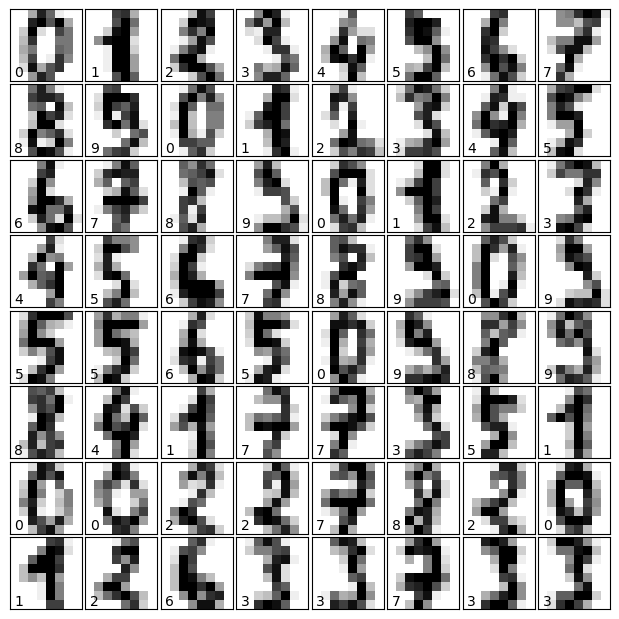

In [45]:
from matplotlib import pyplot as plt

%matplotlib inline
fig = plt.figure(figsize=(6,6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64) :
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation="nearest")
    ax.text(0, 7, str(digits.target[i]))

plt.show()

In [ ]:
# 위에서 찾아온 데이터를 기반으로 특정 머신러닝 모델 학습
# X_train = 랜덤하게 뽑은 data
# X_test = train이 아닌 나머지 data
# y_train = 랜담하게 뽑은 X_train 데이터에 대한 정답
# y_test =  나머지 X_test 데이터에 대한 정답

# sklearn을 통해서 찾아온 숫자 데이터가 약 1347개 정도 있고 학습목적으로 분류 된게 약 1,010개다 학습외 분류된건 약 337개 정도 됨 

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target)

In [47]:
from sklearn.naive_bayes import GaussianNB

OneOfNavieBayesianModels = GaussianNB()

In [ ]:
# NaiveBayes
# 머신러닝 모델 중에서도 특히 확률 기반 분류 모델 중 손꼽히는 모델
# 코드의 난이도 가장 낮음
# 특히 텍스트 분류와 숫자 분류에 높은 성능을 보인다

In [49]:
from sklearn import set_config
set_config(display="text")

In [50]:
OneOfNavieBayesianModels.fit(X_train, y_train)

GaussianNB()

In [51]:
# GaussianNB 모델에서 학습한 내용을 바탕으로 실제 문제에 대한 정답 예측

predicted = OneOfNavieBayesianModels.predict(X_test)

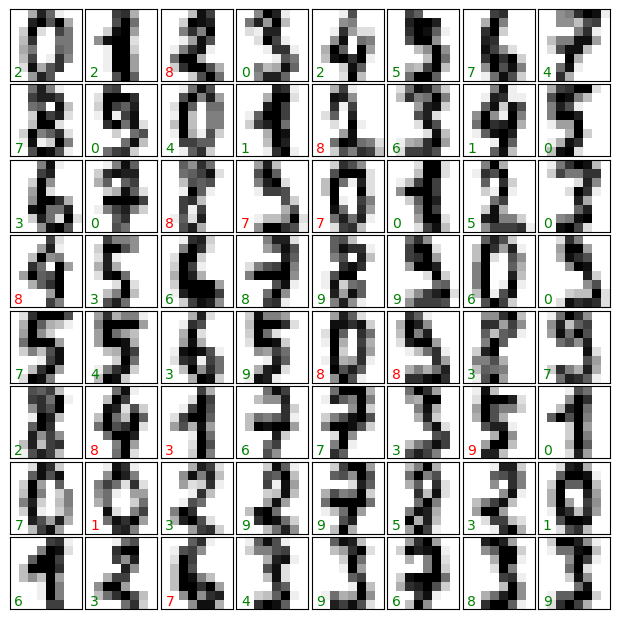

In [55]:
# 추후엔 성능평가가 필요하다
# 예측되어진 결과값 출력

from matplotlib import pyplot as plt

fig = plt.figure(figsize=(6,6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64) : 
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation="nearest")

    if predicted[i] == y_test[i] :
        ax.text(0, 7, str(predicted[i]), color="green")
    else :
        ax.text(0, 7, str(predicted[i]), color="red")

plt.show()

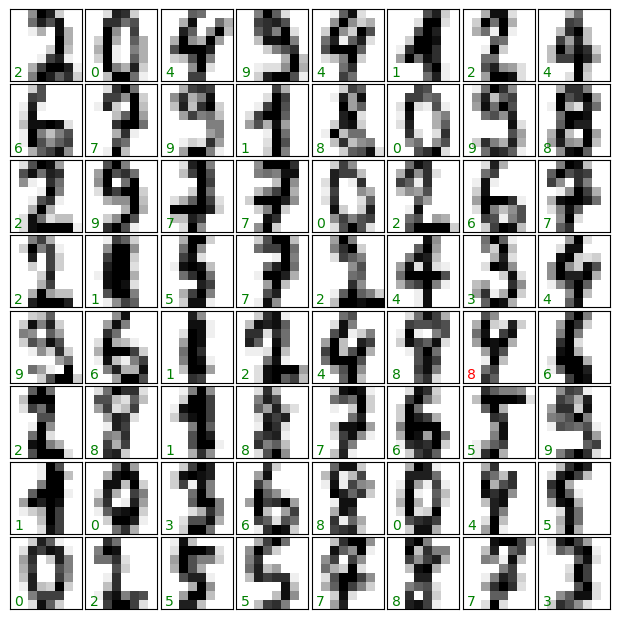

In [64]:
import matplotlib.pyplot as plt # 그림을 그리기 위해 불러온 모듈
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()

X = digits.images.reshape(len(digits.images), -1)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

clf = svm.SVC(gamma=0.001) # 민감도(gamma)가 낮으면 낮을수록 덜 민감하다 0.001 정도가 평균
clf.fit(X_train, y_train)

predicted = clf.predict(X_test)

fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64) : 
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(X_test.reshape(-1, 8, 8) [i], cmap=plt.cm.binary, interpolation="nearest")

    if predicted[i] == y_test[i] :
        ax.text(0, 7, str(predicted[i]), color="green")
    else :
        ax.text(0, 7, str(predicted[i]), color="red")

plt.show()